In [1]:
import sys
from pathlib import Path

# Ensure project root is importable when notebook runs from notebooks/
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("PROJECT_ROOT:", PROJECT_ROOT)


PROJECT_ROOT: d:\Projet\scanned_images_classifier


# OCR Fine-tuning CPU (batch_1 -> batch_2)

Ce notebook entraine un modele OCR image->texte sur `batch_1` avec les annotations CSV, puis teste l'inference sur `batch_2`.

In [2]:
from pathlib import Path
import json

from src.ocr_image_text.config import TrainConfig, InferConfig
from src.ocr_image_text.data import resolve_default_data_root, load_default_train_eval
from src.ocr_image_text.train import run_training
from src.ocr_image_text.inference import load_predictor
from src.ocr_image_text.evaluation import evaluate_records

In [3]:
data_root = resolve_default_data_root()

# Force artifacts in notebooks/artifacts to avoid loading stale smoke models from ./artifacts
repo_root = Path.cwd()
if not (repo_root / "src").exists() and (repo_root.parent / "src").exists():
    repo_root = repo_root.parent
output_dir = (repo_root / "notebooks" / "artifacts" / "doc_understanding_ocr_cpu").resolve()
output_dir.mkdir(parents=True, exist_ok=True)

legacy_output_dir = (repo_root / "artifacts" / "doc_understanding_ocr_cpu").resolve()
if legacy_output_dir.exists() and legacy_output_dir != output_dir:
    print(f"[info] Ignoring legacy artifacts at: {legacy_output_dir}")

print("data_root:", data_root)
print("output_dir (forced):", output_dir)


[info] Ignoring legacy artifacts at: D:\Projet\scanned_images_classifier\artifacts\doc_understanding_ocr_cpu
data_root: C:\Users\Francis BACKELAND\.cache\kagglehub\datasets\osamahosamabdellatif\high-quality-invoice-images-for-ocr\versions\3
output_dir (forced): D:\Projet\scanned_images_classifier\notebooks\artifacts\doc_understanding_ocr_cpu


In [4]:
train_records, eval_records = load_default_train_eval(
    data_root=data_root,
    train_csv="batch_1/batch_1/batch1_1.csv",
    eval_csv="batch_1/batch_1/batch1_2.csv",
    image_subdir_train="batch_1/batch_1/batch1_1",
    image_subdir_eval="batch_1/batch_1/batch1_2",
)

print("num_train_records:", len(train_records))
print("num_eval_records:", len(eval_records))
print("sample_train_image:", train_records[0].image_path)
print("sample_train_text[:200]:", train_records[0].ocr_text[:200])

num_train_records: 499
num_eval_records: 426
sample_train_image: C:\Users\Francis BACKELAND\.cache\kagglehub\datasets\osamahosamabdellatif\high-quality-invoice-images-for-ocr\versions\3\batch_1\batch_1\batch1_1\batch1-0494.jpg
sample_train_text[:200]: Invoice no: 84652373 Date of issue: 02/23/2021 Seller: Client: Nguyen-Roach Clark-Foster 247 David Highway 77477 Cliff Apt. 853 Lake John, WV 84178 Washingtonbury, MS 78346 Tax Id: 991-72-5826 Tax Id:


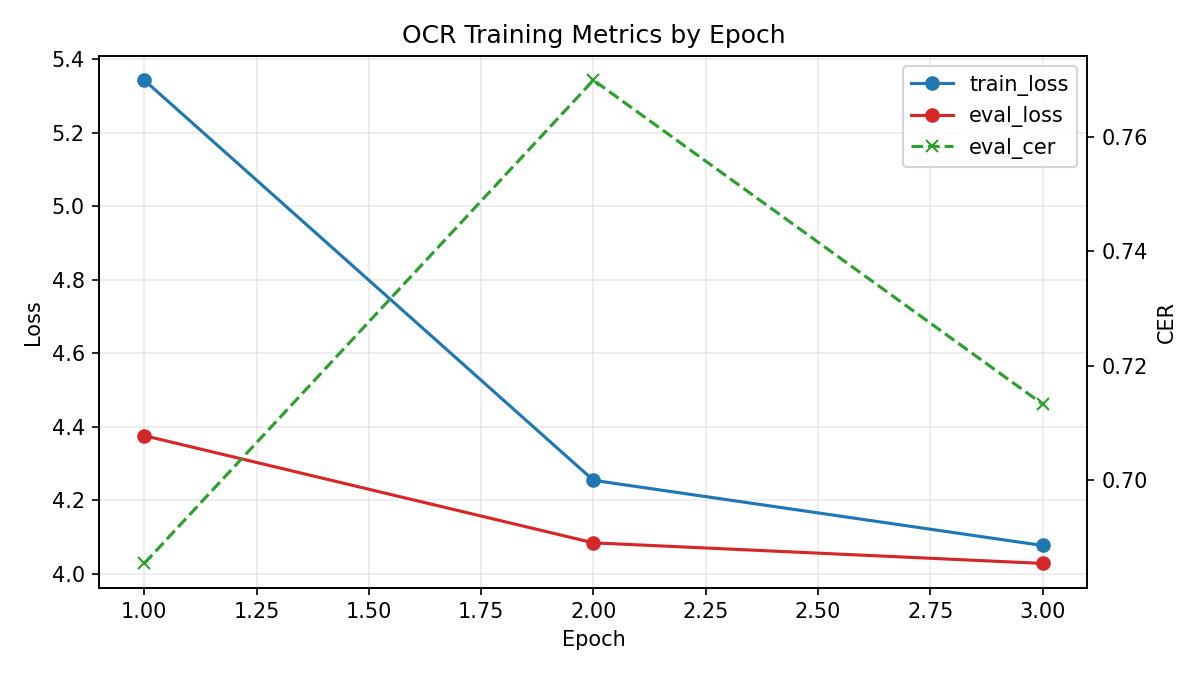

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'config': {'data_root': 'C:\\Users\\Francis BACKELAND\\.cache\\kagglehub\\datasets\\osamahosamabdellatif\\high-quality-invoice-images-for-ocr\\versions\\3',
  'output_dir': 'D:\\Projet\\scanned_images_classifier\\notebooks\\artifacts\\doc_understanding_ocr_cpu',
  'model_name': 'microsoft/trocr-small-printed',
  'train_csv': 'batch_1/batch_1/batch1_1.csv',
  'eval_csv': 'batch_1/batch_1/batch1_2.csv',
  'image_subdir_train': 'batch_1/batch_1/batch1_1',
  'image_subdir_eval': 'batch_1/batch_1/batch1_2',
  'max_train_samples': 512,
  'max_eval_samples': 0,
  'max_target_length': 256,
  'learning_rate': 3e-05,
  'train_epochs': 3,
  'per_device_train_batch_size': 2,
  'per_device_eval_batch_size': 2,
  'random_seed': 3407,
  'lr_scheduler_type': 'cosine',
  'early_stopping_patience': 2,
  'early_stopping_threshold': 0.0,
  'metric_for_best_model': 'eval_cer',
  'greater_is_better': False,
  'generation_num_beams': 4,
  'generation_length_penalty': 1.0,
  'generation_no_repeat_ngram_size'

In [5]:
# Preset CPU stable (short run)
EPOCHS = 3
MAX_TRAIN_SAMPLES = 512
MAX_EVAL_SAMPLES = 0  # <=0 => use full eval split (batch1_2)
TRAIN_BATCH_SIZE = 2
EVAL_BATCH_SIZE = 2
LEARNING_RATE = 3e-5

cfg = TrainConfig(
    data_root=data_root,
    output_dir=output_dir,
    model_name="microsoft/trocr-small-printed",
    train_csv="batch_1/batch_1/batch1_1.csv",
    eval_csv="batch_1/batch_1/batch1_2.csv",
    image_subdir_train="batch_1/batch_1/batch1_1",
    image_subdir_eval="batch_1/batch_1/batch1_2",
    max_train_samples=MAX_TRAIN_SAMPLES,
    max_eval_samples=MAX_EVAL_SAMPLES,
    train_epochs=EPOCHS,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    learning_rate=LEARNING_RATE,
)

summary = run_training(cfg)
summary


plot_path: D:\Projet\scanned_images_classifier\notebooks\artifacts\doc_understanding_ocr_cpu\training_metrics.png
history_path: D:\Projet\scanned_images_classifier\notebooks\artifacts\doc_understanding_ocr_cpu\metrics_history.json


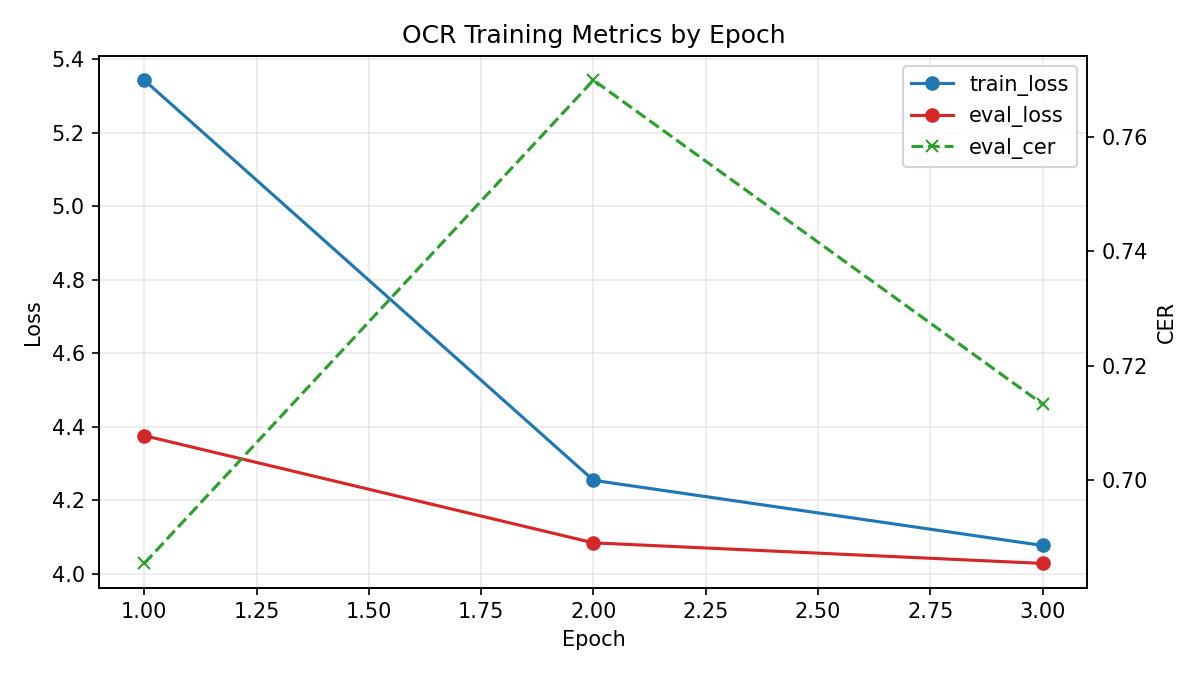

,epoch,loss
0,1.0,5.342772
1,2.0,4.253991
2,3.0,4.076641


,epoch,loss,cer
0,1.0,4.375450,0.685370
1,2.0,4.083841,0.769931
2,3.0,4.027857,0.713257


C:\Users\Francis BACKELAND\AppData\Local\Temp\ipykernel_4648\543699508.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [6]:
from IPython.display import Image, display
import pandas as pd
import matplotlib.pyplot as plt

plot_path = output_dir / "training_metrics.png"
history_path = output_dir / "metrics_history.json"

print("plot_path:", plot_path)
print("history_path:", history_path)
if plot_path.exists():
    display(Image(filename=str(plot_path)))
else:
    print("Plot not found yet.")

if history_path.exists():
    history = json.loads(history_path.read_text(encoding="utf-8"))
    train_df = pd.DataFrame(history.get("train", []))
    eval_df = pd.DataFrame(history.get("eval", []))
    display(train_df.tail())
    display(eval_df.tail())
    if eval_df.empty:
        print("Warning: no eval_loss logged yet. Check eval strategy / completed epoch.")

    plt.figure(figsize=(8,4))
    if not train_df.empty:
        plt.plot(train_df["epoch"], train_df["loss"], marker="o", label="train_loss")
    if not eval_df.empty:
        plt.plot(eval_df["epoch"], eval_df["loss"], marker="o", label="eval_loss")
    plt.title("Train vs Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()
else:
    print("metrics_history.json not found yet.")


In [7]:
# Cellule suivi tests + val loss
import subprocess, sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

cmd = [
    sys.executable, "-m", "unittest", "discover",
    "-s", "tests/apps",
    "-p", "test_doc_understanding_cpu_gradio_smoke.py",
]
res = subprocess.run(cmd, capture_output=True, text=True, cwd=str(PROJECT_ROOT))
print("--- unit tests stdout ---")
print(res.stdout)
print("--- unit tests stderr ---")
print(res.stderr)
print("returncode:", res.returncode)

if "metrics" in globals():
    print("current_val_metrics:", metrics)


--- unit tests stdout ---

--- unit tests stderr ---
..
----------------------------------------------------------------------
Ran 2 tests in 0.000s

OK

returncode: 0


In [8]:
predictor = load_predictor(
    InferConfig(
        artifacts_dir=output_dir,
        max_new_tokens=256,
        num_beams=4,
        length_penalty=1.0,
        no_repeat_ngram_size=3,
        temperature=0.0,
    )
)
eval_subset = eval_records[:20]
preds = {}
for rec in eval_subset:
    out = predictor.predict(rec.image_path)
    preds[rec.img_name] = out.get("prediction", "")
metrics = evaluate_records(eval_subset, preds)
metrics


Loading weights:   0%|          | 0/362 [00:00<?, ?it/s]

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

{'num_samples': 20,
 'exact_match': 0.0,
 'avg_char_accuracy': 0.3209994173151496,
 'avg_word_accuracy': 0.15217249915961029}

In [9]:
metrics_path = output_dir / "eval_metrics.json"
metrics_path.write_text(json.dumps(metrics, indent=2, ensure_ascii=False), encoding="utf-8")
print("saved:", metrics_path)

saved: D:\Projet\scanned_images_classifier\notebooks\artifacts\doc_understanding_ocr_cpu\eval_metrics.json


In [10]:
img_eval = data_root / "batch_1/batch_1/batch1_1/batch1-0001.jpg"
predictor.predict(img_eval)

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{'prediction': "Invoice no: 07/17/07/2012 Seller: Client: Johnson, Jackson, Anderson, Anderson and Johnson, NJ 888 Tax Id: 986 Tax IBAN: 968-97 ITEMS No. Description Qty UM Net price Net worth VAT [%] Gross worth 1,00 each 3,00 each 5,00 each 4,00 each 29,00 each 25,00 each 5 0,00 each 10% 2 0,99 10% 5's SUMMARY VAT Gross worth 10% 5",
 'raw_output': "Invoice no: 07/17/07/2012 Seller: Client: Johnson, Jackson, Anderson, Anderson and Johnson, NJ 888 Tax Id: 986 Tax IBAN: 968-97 ITEMS No. Description Qty UM Net price Net worth VAT [%] Gross worth 1,00 each 3,00 each 5,00 each 4,00 each 29,00 each 25,00 each 5 0,00 each 10% 2 0,99 10% 5's SUMMARY VAT Gross worth 10% 5",
 'latency_ms': 12445.9}

In [11]:
# Test inference sur une image batch_2
batch2_image = data_root / "batch_2/batch_2/batch2_1/batch2-0001.jpg"
result_batch2 = predictor.predict(batch2_image)
result_batch2

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{'prediction': "Invoice no: 07/07/06/2012 Seller: Client: Johnson, Anderson, Jackson, Anderson and Johnson, Johnson and Sons, AZ 666 Tax Id: 946 Tax IBAN: 945-97-97 ITEMS No. Description Qty UM Net price Net worth VAT [%] Gross worth 10% 1 0,00 each 4,00 each 5,00 each 25,99 10% 5 0,95 10% 2 0,99 10% 2 3 0,98 10% 2 6 0,90 10% 5'%] Net worth 10% 5",
 'raw_output': "Invoice no: 07/07/06/2012 Seller: Client: Johnson, Anderson, Jackson, Anderson and Johnson, Johnson and Sons, AZ 666 Tax Id: 946 Tax IBAN: 945-97-97 ITEMS No. Description Qty UM Net price Net worth VAT [%] Gross worth 10% 1 0,00 each 4,00 each 5,00 each 25,99 10% 5 0,95 10% 2 0,99 10% 2 3 0,98 10% 2 6 0,90 10% 5'%] Net worth 10% 5",
 'latency_ms': 16612.665}

## Lancer Gradio avec ce modele

```bash
python src/apps/doc_understanding_cpu_gradio.py --model-dir notebooks/artifacts/doc_understanding_ocr_cpu/model --model-meta-path notebooks/artifacts/doc_understanding_ocr_cpu/model_meta.json --host 127.0.0.1 --port 7862
```
